<a href="https://colab.research.google.com/github/NisithDivantha/Building-a-Neural-Network-from-Scratch/blob/main/adv_ml_assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
from PIL import Image
import random

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
latent_dim = 100
image_size = 28
channels = 1
batch_size = 64
num_epochs = 100
learning_rate = 0.0002
beta1 = 0.5

## Data preprocessing

Raw Image → ToTensor() → Normalize() → Final Tensor

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])

## Download MNIST dataset

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                         transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


## Load MNIST dataset

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                         shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
                        shuffle=False)

# 1.: Generative Adversarial Network (GAN) for MNIST

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # Reshape z to (batch_size, latent_dim, 1, 1) for ConvTranspose2d
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 7, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.model(x)
        return out.view(out.size(0), -1)

In [ ]:
# Initialize networks
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
# Loss function
adversarial_loss = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, 0.999))

In [ ]:
def train_gan():
    print("Starting GAN training...")

    # Training history
    g_losses = []
    d_losses = []
    d_accuracies = []
    g_accuracies = []

    for epoch in range(num_epochs):
        g_loss_epoch = 0
        d_loss_epoch = 0
        d_correct_real = 0
        d_correct_fake = 0
        g_fool_discriminator = 0
        total_samples = 0

        for i, (imgs, _) in enumerate(train_loader):
            batch_size_actual = imgs.size(0)
            total_samples += batch_size_actual

            # Ground truth labels
            real_labels = torch.ones(batch_size_actual, 1).to(device)
            fake_labels = torch.zeros(batch_size_actual, 1).to(device)

            # Real images
            real_imgs = imgs.to(device)

            # Train Discriminator
            optimizer_D.zero_grad()

            # Real images
            real_pred = discriminator(real_imgs)
            d_real_loss = adversarial_loss(real_pred, real_labels)

            # Calculate discriminator accuracy on real images
            d_correct_real += ((real_pred > 0.5).float() == real_labels).sum().item()

            # Fake images
            z = torch.randn(batch_size_actual, latent_dim).to(device)
            fake_imgs = generator(z)
            fake_pred = discriminator(fake_imgs.detach())
            d_fake_loss = adversarial_loss(fake_pred, fake_labels)

            # Calculate discriminator accuracy on fake images
            d_correct_fake += ((fake_pred < 0.5).float() == (1 - fake_labels)).sum().item()

            # Total discriminator loss
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()

            # Generate fake images
            z = torch.randn(batch_size_actual, latent_dim).to(device)
            fake_imgs = generator(z)
            fake_pred = discriminator(fake_imgs)

            # Calculate generator accuracy (how well it fools discriminator)
            g_fool_discriminator += ((fake_pred > 0.5).float() == real_labels).sum().item()

            # Generator loss
            g_loss = adversarial_loss(fake_pred, real_labels)
            g_loss.backward()
            optimizer_G.step()

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()

        # Calculate average losses for the epoch
        avg_g_loss = g_loss_epoch / len(train_loader)
        avg_d_loss = d_loss_epoch / len(train_loader)

        # Calculate accuracies
        # Discriminator accuracy: (correct real + correct fake) / (total real + total fake)
        d_accuracy = (d_correct_real + d_correct_fake) / (2 * total_samples) * 100

        # Generator accuracy: how often it fools the discriminator
        g_accuracy = g_fool_discriminator / total_samples * 100

        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        d_accuracies.append(d_accuracy)
        g_accuracies.append(g_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] - G_loss: {avg_g_loss:.4f}, D_loss: {avg_d_loss:.4f}, '
              f'D_acc: {d_accuracy:.2f}%, G_acc: {g_accuracy:.2f}%')

    return g_losses, d_losses, d_accuracies, g_accuracies


In [106]:
g_losses, d_losses, d_accuracies, g_accuracies = train_gan()

Starting GAN training...
Epoch [1/100] - G_loss: 3.1979, D_loss: 0.2840, D_acc: 89.51%, G_acc: 7.27%
Epoch [2/100] - G_loss: 1.9472, D_loss: 0.2824, D_acc: 91.21%, G_acc: 7.32%
Epoch [3/100] - G_loss: 2.0817, D_loss: 0.2661, D_acc: 91.30%, G_acc: 6.94%
Epoch [4/100] - G_loss: 2.1289, D_loss: 0.2730, D_acc: 90.47%, G_acc: 7.91%
Epoch [5/100] - G_loss: 2.1769, D_loss: 0.2765, D_acc: 89.93%, G_acc: 8.09%
Epoch [6/100] - G_loss: 2.2733, D_loss: 0.2651, D_acc: 90.23%, G_acc: 8.47%
Epoch [7/100] - G_loss: 2.3317, D_loss: 0.2646, D_acc: 90.21%, G_acc: 8.29%
Epoch [8/100] - G_loss: 2.3594, D_loss: 0.2614, D_acc: 90.22%, G_acc: 8.92%
Epoch [9/100] - G_loss: 2.3969, D_loss: 0.2525, D_acc: 90.70%, G_acc: 8.62%
Epoch [10/100] - G_loss: 2.4924, D_loss: 0.2487, D_acc: 90.72%, G_acc: 8.30%
Epoch [11/100] - G_loss: 2.5403, D_loss: 0.2394, D_acc: 91.26%, G_acc: 7.92%
Epoch [12/100] - G_loss: 2.5939, D_loss: 0.2369, D_acc: 91.17%, G_acc: 8.35%
Epoch [13/100] - G_loss: 2.6419, D_loss: 0.2343, D_acc: 91.3

In [110]:
print("\nAccuracies per Epoch:")
for epoch, (d_acc, g_acc) in enumerate(zip(d_accuracies, g_accuracies)):
    print(f"Epoch {epoch + 1}: D_acc: {d_acc:.2f}%, G_acc: {g_acc:.2f}%")


Accuracies per Epoch:
Epoch 1: D_acc: 89.51%, G_acc: 7.27%
Epoch 2: D_acc: 91.21%, G_acc: 7.32%
Epoch 3: D_acc: 91.30%, G_acc: 6.94%
Epoch 4: D_acc: 90.47%, G_acc: 7.91%
Epoch 5: D_acc: 89.93%, G_acc: 8.09%
Epoch 6: D_acc: 90.23%, G_acc: 8.47%
Epoch 7: D_acc: 90.21%, G_acc: 8.29%
Epoch 8: D_acc: 90.22%, G_acc: 8.92%
Epoch 9: D_acc: 90.70%, G_acc: 8.62%
Epoch 10: D_acc: 90.72%, G_acc: 8.30%
Epoch 11: D_acc: 91.26%, G_acc: 7.92%
Epoch 12: D_acc: 91.17%, G_acc: 8.35%
Epoch 13: D_acc: 91.31%, G_acc: 7.99%
Epoch 14: D_acc: 91.75%, G_acc: 7.69%
Epoch 15: D_acc: 91.44%, G_acc: 8.25%
Epoch 16: D_acc: 91.75%, G_acc: 8.11%
Epoch 17: D_acc: 91.68%, G_acc: 7.70%
Epoch 18: D_acc: 91.61%, G_acc: 7.85%
Epoch 19: D_acc: 91.74%, G_acc: 7.87%
Epoch 20: D_acc: 92.55%, G_acc: 7.54%
Epoch 21: D_acc: 92.10%, G_acc: 7.30%
Epoch 22: D_acc: 92.08%, G_acc: 7.42%
Epoch 23: D_acc: 92.24%, G_acc: 7.07%
Epoch 24: D_acc: 92.34%, G_acc: 7.50%
Epoch 25: D_acc: 92.14%, G_acc: 7.42%
Epoch 26: D_acc: 92.30%, G_acc: 7.43

## 2. Create and Annotate a Fake Dataset

### Steps and Code Breakdown

1. **Load the Generator Model**  
   - Load the pre-trained Generator model (`G.pkl`).  
   - This model generates new images from random noise.

2. **Initialize the Dataset Directories**  
   - The `initialize_fake_dataset_manual()` function creates the directory structure:  
     - **Base folder:** `Fake_Digits`  
     - **Subfolders:** `0` through `9` for each digit class.

3. **Generate and Display Images**  
   - The `generate_fake_dataset_manual()` function generates a batch of fake images.  
   - Images are displayed in a grid with their batch index shown.  
   - I visually inspected these images to decide which ones are valid digits.

4. **Manual Selection and Labeling**  
   - After reviewing the grid, manually select valid images by specifying:  
     - **Index:** Position of the image in the batch.  
     - **Label:** Digit class (0–9).  
   - The format for input is:  
     ```
     index-label
     ```

5. **Save Selected Images and Latent Vectors**  
   - For each selected image:  
     - Save the image as a **PNG file** in the correct digit subfolder.  
     - Save the corresponding **latent vector** (noise input) as a `.txt` file in the same folder.  
   - Files are named with a unique, incrementing index (e.g., `001`, `002`, … up to `100`).

6. Continued this process till 100 identifiable digits are chosen.


In [ ]:
import pickle
import torch

# Load the generator model
try:
    with open('/content/G.pkl', 'rb') as f:
        generator = pickle.load(f)
    generator.to(device) # Move the generator to the appropriate device
    print("Generator model loaded successfully!")
except FileNotFoundError:
    print("Generator model file not found. Please make sure 'G.pkl' is in the correct location.")
except Exception as e:
    print(f"Error loading generator model: {e}")

Generator model loaded successfully!


In [ ]:
def save_selected_images(generated_images, selected_indices, latent_vectors, base_dir='Fake_Digits_Classified'):
    """Saves selected well-formed images and their latent vectors with unique sequential indices."""
    global generated_count # Use the global counter

    if selected_indices is None:
        return

    for idx in selected_indices:
        if 0 <= idx < generated_images.shape[0] and generated_count < 100:
            label_input = input(f"Enter the label for image index {idx}: ")
            try:
                label = int(label_input.strip())
                if not (0 <= label <= 9):
                    print(f"Invalid label: {label_input}. Please enter a digit between 0 and 9.")
                    continue
            except ValueError:
                print(f"Invalid input for label: {label_input}. Please enter a digit.")
                continue

            generated_count += 1 # Increment the global counter for unique indexing

            # Save image
            img_array = generated_images[idx][0]
            img_array = (img_array * 255).astype(np.uint8)
            img = Image.fromarray(img_array, mode='L')
            img_name = f'{generated_count:03d}.png' # Use global counter for unique index
            img_path = os.path.join(base_dir, str(label), img_name)
            img.save(img_path)

            # Save latent vector
            latent_name = f'{generated_count:03d}.txt' # Use global counter for unique index
            latent_path = os.path.join(base_dir, str(label), latent_name)
            z_cpu = latent_vectors[idx]
            np.savetxt(latent_path, z_cpu)

            print(f"Saved image for label {label}, unique index {generated_count}. Total saved: {generated_count}")
        elif generated_count >= 100:
             print("Already generated 100 well-formed images.")
             break # Exit the loop if 100 are already saved


def generate_and_display_batch(generator, latent_dim, device, batch_size):
    """Generates and displays a batch of fake images."""
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim).to(device)
        generated_images = generator(z).detach().cpu().numpy()

    # Display images
    fig = plt.figure(figsize=(10, 10))
    for i in range(generated_images.shape[0]):
        plt.subplot(8, 8, i+1)
        img = (generated_images[i][0] + 1) / 2.0
        plt.imshow(img, cmap='gray')
        plt.title(f'Idx: {i}')
        plt.axis('off')
    plt.show()

    return generated_images, z.cpu().numpy()


# Initialize global counters and directories
generated_count = 0
digit_counts = {i: 0 for i in range(10)}

def initialize_fake_dataset_manual():
    """Initializes directories for manual fake dataset generation."""
    global generated_count
    global digit_counts
    print("Initializing manual selection process...")

    # Create base directory for classified fake digits
    base_dir = 'Fake_Digits'
    os.makedirs(base_dir, exist_ok=True)
    for i in range(10):
        os.makedirs(os.path.join(base_dir, str(i)), exist_ok=True)

    generator.eval()
    digit_counts = {i: 0 for i in range(10)}
    generated_count = 0


    print("Initialization complete. Ready to generate batches.")

In [ ]:
initialize_fake_dataset_manual()

Initializing manual selection process...
Initialization complete. Ready to generate batches.


In [ ]:
def generate_fake_dataset_manual():
    """Generate fake digits with manual selection and save well-formed ones."""
    global generated_count
    global digit_counts
    global latest_generated_images
    global latest_latent_vectors

    if generated_count >= 100:
        print("Already generated 100 well-formed images.")
        return

    # Generate and display a batch of images
    latest_generated_images, latest_latent_vectors = generate_and_display_batch(generator, latent_dim, device, batch_size)

    print("\nReview the images above and run the next cell to select and label well-formed ones.")
    print(f"Total saved so far: {generated_count}")

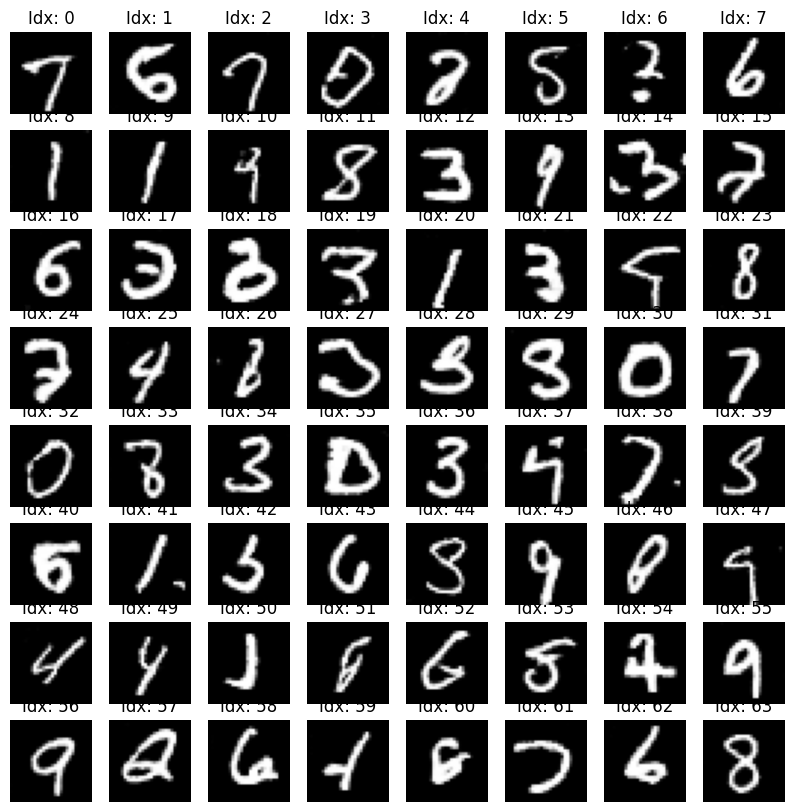


Review the images above and run the next cell to select and label well-formed ones.
Total saved so far: 97


In [ ]:
# Call the manual selection function
generate_fake_dataset_manual()

In [ ]:
print("--- Enter selection and labels below the images ---")
user_input = input("Enter indices and labels (e.g., '0-2 1-3'), or 'q' to stop: ")

# Process user input
if user_input.lower() == 'q':
    selected_pairs = None
    print("Manual selection process interrupted by user.")
else:
    selected_pairs = []
    input_parts = user_input.split()
    for part in input_parts:
        if '-' in part:
            try:
                index_str, label_str = part.split('-')
                index = int(index_str.strip())
                label = int(label_str.strip())
                selected_pairs.append((index, label))
            except ValueError:
                print(f"Invalid format for '{part}'. Please use index-label format (e.g., '0-2').")
        else:
            print(f"Invalid format for '{part}'. Please use index-label format (e.g., '0-2').")

if selected_pairs:
    selected_indices = [pair[0] for pair in selected_pairs]
    selected_labels = {pair[0]: pair[1] for pair in selected_pairs}

    base_dir = 'Fake_Digits'

    for idx in selected_indices:
        if 0 <= idx < latest_generated_images.shape[0] and generated_count < 100:
            label = selected_labels.get(idx)
            if label is None:
                 print(f"No label provided for image index {idx}. Skipping.")
                 continue

            if not (0 <= label <= 9):
                print(f"Invalid label: {label}. Please enter a digit between 0 and 9 for index {idx}.")
                continue # Skip saving this image

            digit_counts[label] += 1
            generated_count += 1
            index = generated_count

            # Save image
            img_array = latest_generated_images[idx][0]
            img_array = (img_array * 255).astype(np.uint8)
            img = Image.fromarray(img_array, mode='L')
            img_name = f'{index:03d}.png'
            img_path = os.path.join(base_dir, str(label), img_name)
            img.save(img_path)

            # Save latent vector
            latent_name = f'{index:03d}.txt'
            latent_path = os.path.join(base_dir, str(label), latent_name)
            z_cpu = latest_latent_vectors[idx]
            np.savetxt(latent_path, z_cpu)


            print(f"Saved image for label {label}, index {index}. Total saved: {generated_count}")
        elif generated_count >= 100:
             print("Already generated 100 well-formed images.")
             break # Exit the loop if 100 are already saved


else:
    print("No valid index-label pairs entered or user quit. No images saved from this batch.")

print(f"Total saved so far: {generated_count}")

--- Enter your selection and labels below the images ---
Enter indices and labels (e.g., '0-2 1-3'), or 'q' to stop: q
Manual selection process interrupted by user.
No valid index-label pairs entered or user quit. No images saved from this batch.
Total saved so far: 100


In [ ]:
from google.colab import files

# Compress the folder before downloading (optional but recommended for folders)
!zip -r /content/Fake_Digits.zip /content/Fake_Digits

# Download the compressed file
files.download('/content/Fake_Digits.zip')

  adding: content/Fake_Digits/ (stored 0%)
  adding: content/Fake_Digits/6/ (stored 0%)
  adding: content/Fake_Digits/6/037.txt (deflated 53%)
  adding: content/Fake_Digits/6/007.txt (deflated 53%)
  adding: content/Fake_Digits/6/059.txt (deflated 53%)
  adding: content/Fake_Digits/6/059.png (stored 0%)
  adding: content/Fake_Digits/6/030.png (stored 0%)
  adding: content/Fake_Digits/6/007.png (stored 0%)
  adding: content/Fake_Digits/6/037.png (stored 0%)
  adding: content/Fake_Digits/6/030.txt (deflated 53%)
  adding: content/Fake_Digits/0/ (stored 0%)
  adding: content/Fake_Digits/0/003.png (stored 0%)
  adding: content/Fake_Digits/0/082.png (stored 0%)
  adding: content/Fake_Digits/0/017.png (stored 0%)
  adding: content/Fake_Digits/0/036.png (stored 0%)
  adding: content/Fake_Digits/0/005.txt (deflated 54%)
  adding: content/Fake_Digits/0/071.txt (deflated 54%)
  adding: content/Fake_Digits/0/012.png (stored 0%)
  adding: content/Fake_Digits/0/031.png (stored 0%)
  adding: content

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def create_10x10_grid():
    """Create a 10x10 grid of generated digits"""
    print("Creating 10x10 grid...")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(100, latent_dim).to(device)
        fake_images = generator(z)

        # Denormalize
        fake_images = (fake_images + 1) / 2

        # Create grid
        grid = torchvision.utils.make_grid(fake_images, nrow=10, normalize=True, padding=2)
        torchvision.utils.save_image(grid, '10x10_generated_digits.png')

    print("10x10 grid saved as '10x10_generated_digits.png'")

In [ ]:
create_10x10_grid()

Creating 10x10 grid...
10x10 grid saved as '10x10_generated_digits.png'


# 3. Evaluate the new fake data set


In [ ]:
# CNN Classifier for MNIST
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [ ]:
def train_classifier():
    """Train CNN classifier on MNIST"""
    print("Training CNN classifier...")

    classifier = CNNClassifier().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)

    # Training history
    train_accuracies = []

    classifier.train()
    for epoch in range(10):  # Train for 10 epochs
        correct = 0
        total = 0
        epoch_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = classifier(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        train_accuracies.append(accuracy)
        print(f'Epoch [{epoch+1}/10] - Loss: {epoch_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%')

    return classifier, train_accuracies



In [ ]:
classifier, train_accuracies, test_accuracy = train_classifier()


Training CNN classifier...
Epoch [1/10] - Loss: 0.2505, Accuracy: 92.15%
Epoch [2/10] - Loss: 0.0880, Accuracy: 97.44%
Epoch [3/10] - Loss: 0.0690, Accuracy: 97.99%
Epoch [4/10] - Loss: 0.0599, Accuracy: 98.27%
Epoch [5/10] - Loss: 0.0504, Accuracy: 98.48%
Epoch [6/10] - Loss: 0.0479, Accuracy: 98.62%
Epoch [7/10] - Loss: 0.0425, Accuracy: 98.76%
Epoch [8/10] - Loss: 0.0381, Accuracy: 98.84%
Epoch [9/10] - Loss: 0.0353, Accuracy: 98.96%
Epoch [10/10] - Loss: 0.0314, Accuracy: 99.06%
Test Accuracy: 99.38%


In [113]:
# Test accuracy
classifier.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(total)
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')



10000
Test Accuracy: 99.38%


## 3.2 Use the Python pickle package to save the classifier C as C.pkl.

In [ ]:
with open('C.pkl', 'wb') as f:
    pickle.dump(classifier, f)


## 3.1 From the real MNIST (test) data set, extract 100 random digit images and name the data set as S0



In [ ]:
def evaluate_datasets(classifier):
    """Evaluate S0 and S1 datasets"""
    print("Evaluating datasets...")

    # S0: 100 random images from MNIST test set
    test_images = []
    test_labels = []

    # Collect all test data
    for images, labels in test_loader:
        test_images.append(images)
        test_labels.append(labels)

    all_test_images = torch.cat(test_images, dim=0)
    all_test_labels = torch.cat(test_labels, dim=0)

    # Randomly select 100 images
    indices = torch.randperm(len(all_test_images))[:100]
    s0_images = all_test_images[indices]
    s0_labels = all_test_labels[indices]

    # Evaluate S0
    classifier.eval()
    with torch.no_grad():
        s0_images = s0_images.to(device)
        s0_outputs = classifier(s0_images)
        _, s0_predicted = torch.max(s0_outputs, 1)
        s0_correct = (s0_predicted == s0_labels.to(device)).sum().item()
        s0_error = (100 - s0_correct) / 100

    # S1: Load fake digits and evaluate
    fake_images = []
    fake_dir = 'Fake_Digits'
    fake_labels = [] # We need to extract labels from the directory structure

    if os.path.exists(fake_dir):
        for digit in range(10):
            digit_dir = os.path.join(fake_dir, str(digit))
            if os.path.exists(digit_dir):
                images = [f for f in os.listdir(digit_dir) if f.endswith('.png')]
                for img_name in images:
                    img_path = os.path.join(digit_dir, img_name)
                    try:
                        img = Image.open(img_path).convert('L')
                        img_tensor = transform(img)
                        fake_images.append(img_tensor)
                        fake_labels.append(digit) # Label is the name of the digit folder
                    except Exception as e:
                        print(f"Error loading image {img_path}: {e}")
        # Evaluate S1
        if fake_images:
            fake_images_tensor = torch.stack(fake_images).to(device)
            fake_labels_tensor = torch.tensor(fake_labels).to(device)

            with torch.no_grad():
                s1_outputs = classifier(fake_images_tensor)
                _, s1_predicted = torch.max(s1_outputs, 1)
                s1_correct = (s1_predicted == fake_labels_tensor).sum().item()
                s1_total = len(fake_images)
                s1_error = (s1_total - s1_correct) / s1_total
        else:
            print("No fake images found to evaluate S1.")
    else:
        print(f"Fake digits directory '{fake_dir}' not found.")


    print(f'S0 Classification Error: {s0_error:.2f}')
    print(f'S1 Classification Error: {s1_error:.2f}')

    return s0_error, s1_error

## 3.3 Obtain the classification errors for S0 and S1.

In [ ]:
s0_error, s1_error = evaluate_datasets(classifier)

Evaluating datasets...
S0 Classification Error: 0.01
S1 Classification Error: 0.04
